In [39]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

In [40]:
df = pd.read_csv(
    r"C:\Users\ASUS\Downloads\Cardio_dataset.csv"
)

In [41]:
#Checking data

df.head()

,id;age;gender;height;weight;ap_hi;ap_lo;cholesterol;gluc;smoke;alco;active;cardio
0,0;18393;2;168;62.0;110;80;1;1;0;0;1;0
1,1;20228;1;156;85.0;140;90;3;1;0;0;1;1
2,2;18857;1;165;64.0;130;70;3;1;0;0;0;1
3,3;17623;2;169;82.0;150;100;1;1;0;0;1;1
4,4;17474;1;156;56.0;100;60;1;1;0;0;0;0


In [42]:
df = pd.read_csv(r"C:\Users\ASUS\Downloads\Cardio_dataset.csv" ,sep=';')
df.head()

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1
3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1
4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0


In [43]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70000 entries, 0 to 69999
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   id           70000 non-null  int64  
 1   age          70000 non-null  int64  
 2   gender       70000 non-null  int64  
 3   height       70000 non-null  int64  
 4   weight       70000 non-null  float64
 5   ap_hi        70000 non-null  int64  
 6   ap_lo        70000 non-null  int64  
 7   cholesterol  70000 non-null  int64  
 8   gluc         70000 non-null  int64  
 9   smoke        70000 non-null  int64  
 10  alco         70000 non-null  int64  
 11  active       70000 non-null  int64  
 12  cardio       70000 non-null  int64  
dtypes: float64(1), int64(12)
memory usage: 6.9 MB


In [44]:
df.duplicated().sum()

np.int64(0)

In [45]:
df['cardio'].value_counts()

cardio
0    35021
1    34979
Name: count, dtype: int64

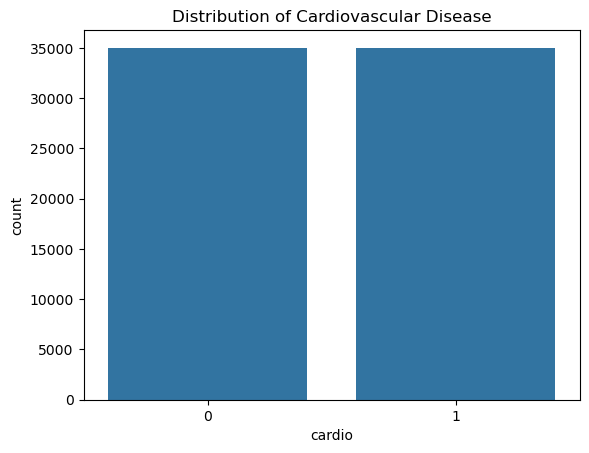

In [46]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='cardio', data=df)

plt.title('Distribution of Cardiovascular Disease')

plt.show()

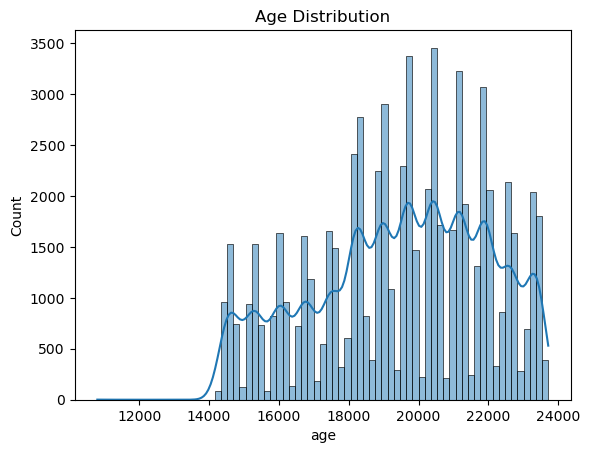

In [47]:
sns.histplot(df['age'], kde=True)

plt.title('Age Distribution')

plt.show()

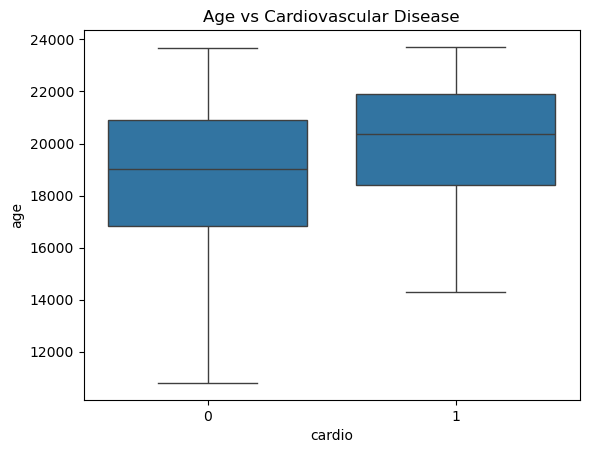

In [48]:
sns.boxplot(x='cardio', y='age', data=df)

plt.title('Age vs Cardiovascular Disease')

plt.show()

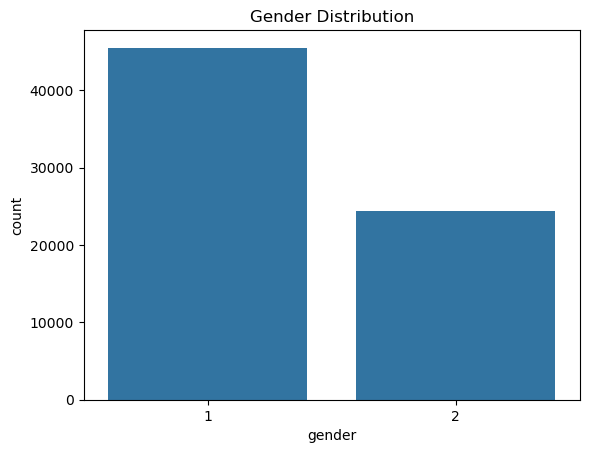

In [49]:
sns.countplot(x='gender', data=df)

plt.title('Gender Distribution')

plt.show()

In [50]:
df['age_years'] = df['age'] / 365

In [51]:
df[['age', 'age_years']].head()

,age,age_years
0,18393,50.391781
1,20228,55.419178
2,18857,51.663014
3,17623,48.282192
4,17474,47.873973


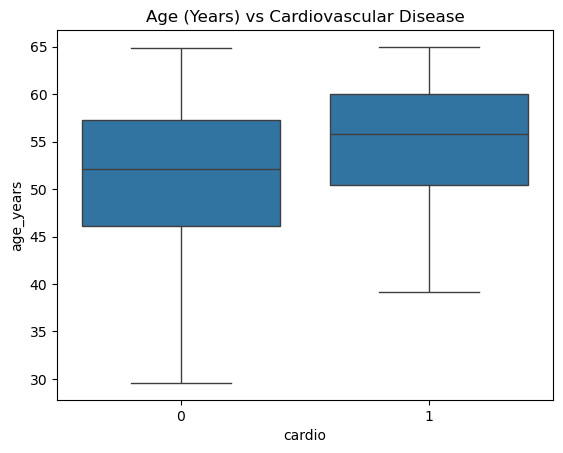

In [52]:
sns.boxplot(x='cardio', y='age_years', data=df)

plt.title('Age (Years) vs Cardiovascular Disease')

plt.show()

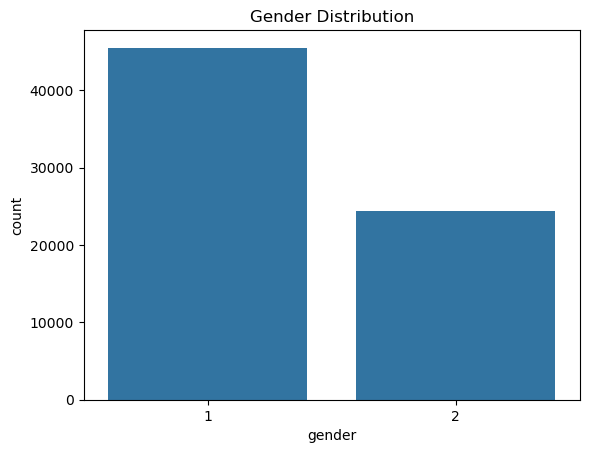

In [53]:
sns.countplot(x='gender', data=df)

plt.title('Gender Distribution')

plt.show()

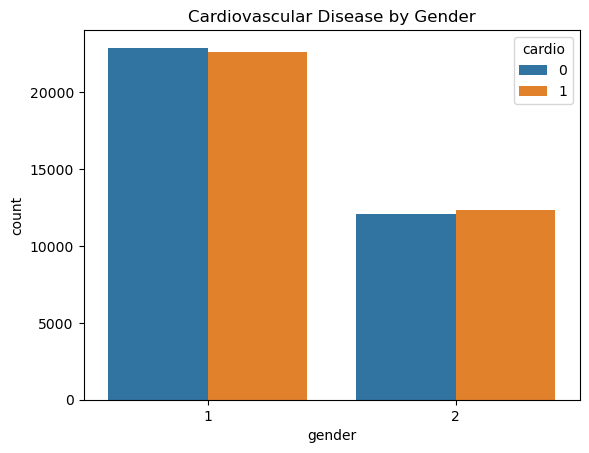

In [54]:
sns.countplot(x='gender', hue='cardio', data=df)

plt.title('Cardiovascular Disease by Gender')

plt.show()

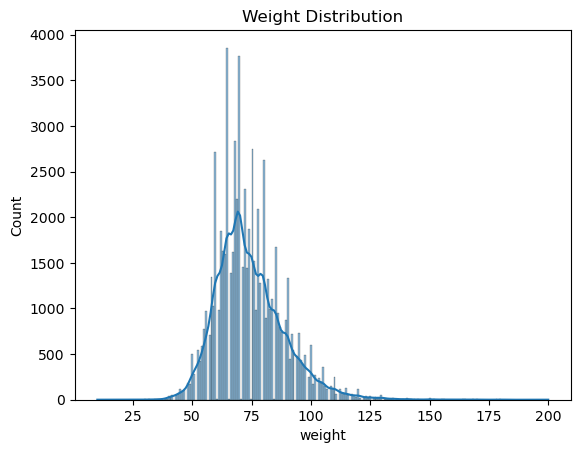

In [55]:
sns.histplot(df['weight'], kde=True)
plt.title('Weight Distribution')
plt.show()

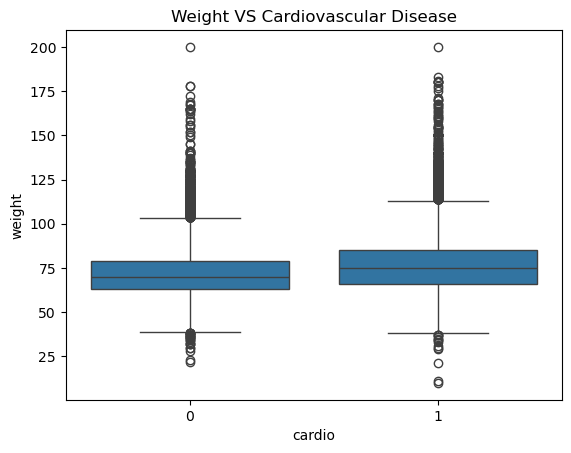

In [56]:
sns.boxplot(x='cardio',y='weight',data=df)
plt.title('Weight VS Cardiovascular Disease')
plt.show()

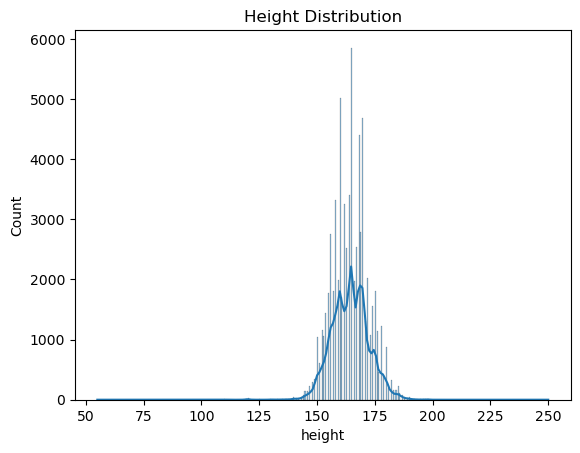

In [57]:
sns.histplot(df['height'],kde=True)
plt.title('Height Distribution')
plt.show()

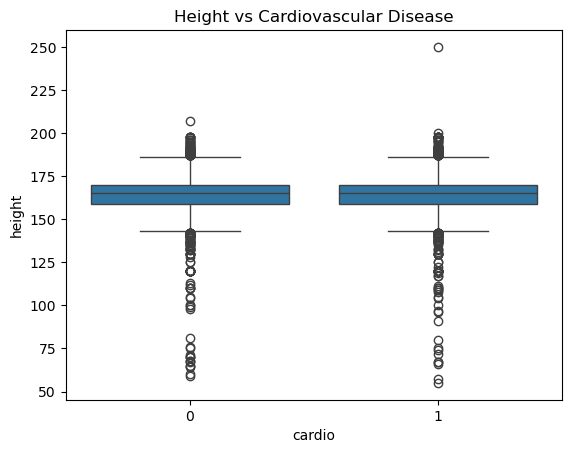

In [58]:
sns.boxplot(x='cardio', y='height', data=df)

plt.title('Height vs Cardiovascular Disease')

plt.show()

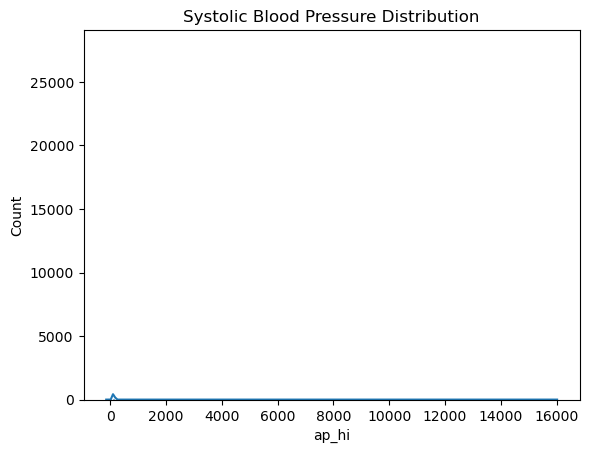

In [59]:
sns.histplot(df['ap_hi'], kde=True)

plt.title('Systolic Blood Pressure Distribution')

plt.show()

In [60]:
df['ap_hi'].describe()

count    70000.000000
mean       128.817286
std        154.011419
min       -150.000000
25%        120.000000
50%        120.000000
75%        140.000000
max      16020.000000
Name: ap_hi, dtype: float64

In [61]:
(df['ap_hi'] > 250).sum()

np.int64(40)

In [62]:
(df['ap_hi'] < 50).sum()

np.int64(188)

In [63]:
df[df['ap_hi'] > 250][['ap_hi']].head(10)

,ap_hi
1876,902
2014,906
4817,909
7763,11500
8915,1420
9557,701
13895,1500
17713,907
23867,906
25464,14020


In [64]:
df_clean = df[(df['ap_hi'] >= 50) & (df['ap_hi'] <= 250)]

In [65]:
df_clean.shape

(69772, 14)

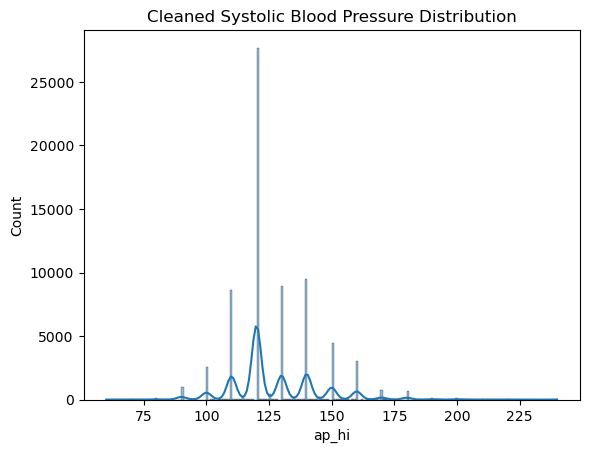

In [66]:
sns.histplot(df_clean['ap_hi'], kde=True)

plt.title('Cleaned Systolic Blood Pressure Distribution')

plt.show()

In [67]:
df['ap_lo'].describe()

count    70000.000000
mean        96.630414
std        188.472530
min        -70.000000
25%         80.000000
50%         80.000000
75%         90.000000
max      11000.000000
Name: ap_lo, dtype: float64

In [68]:
(df['ap_lo'] > 200).sum()

np.int64(953)

In [69]:
(df['ap_lo'] < 40).sum()

np.int64(59)

In [70]:
df[df['ap_lo'] > 200][['ap_hi', 'ap_lo']].head(10)

,ap_hi,ap_lo
228,160,1100
241,160,1000
260,140,800
329,160,1000
345,140,1000
473,150,1033
559,200,1000
613,140,1000
649,190,1100
653,180,1000


In [71]:
df_clean = df[
    (df['ap_hi'] >= 50) &
    (df['ap_hi'] <= 250) &
    (df['ap_lo'] >= 40) &
    (df['ap_lo'] <= 200)
]

In [72]:
df_clean.shape

(68775, 14)

In [73]:
df_clean[['ap_hi', 'ap_lo']].describe()

,ap_hi,ap_lo
count,68775.000000,68775.000000
mean,126.614846,81.382043
std,16.763475,9.676889
min,60.000000,40.000000
25%,120.000000,80.000000
50%,120.000000,80.000000
75%,140.000000,90.000000
max,240.000000,190.000000


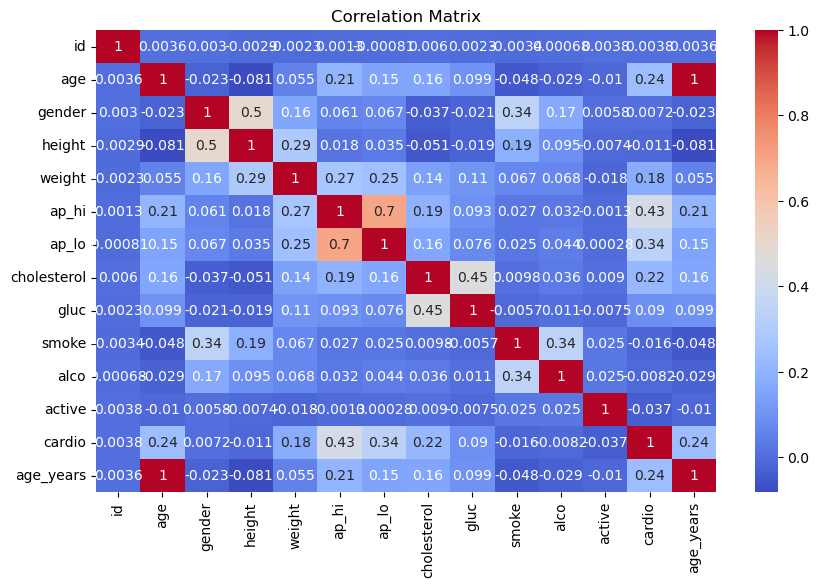

In [74]:
plt.figure(figsize=(10,6))

sns.heatmap(
    df_clean.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title('Correlation Matrix')

plt.show()

In [75]:
df_ml = df_clean.drop(['id', 'age'], axis=1)

df_ml.head()

,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio,age_years
0,2,168,62.0,110,80,1,1,0,0,1,0,50.391781
1,1,156,85.0,140,90,3,1,0,0,1,1,55.419178
2,1,165,64.0,130,70,3,1,0,0,0,1,51.663014
3,2,169,82.0,150,100,1,1,0,0,1,1,48.282192
4,1,156,56.0,100,60,1,1,0,0,0,0,47.873973


In [76]:
x = df_ml.drop('cardio', axis=1)
y = df_ml['cardio']

In [77]:
df_ml.head()

,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio,age_years
0,2,168,62.0,110,80,1,1,0,0,1,0,50.391781
1,1,156,85.0,140,90,3,1,0,0,1,1,55.419178
2,1,165,64.0,130,70,3,1,0,0,0,1,51.663014
3,2,169,82.0,150,100,1,1,0,0,1,1,48.282192
4,1,156,56.0,100,60,1,1,0,0,0,0,47.873973


In [79]:
X = df_ml.drop('cardio', axis=1)

y = df_ml['cardio']

In [80]:
x.shape

(68775, 11)

In [81]:
y.shape

(68775,)

In [82]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [85]:
X_train.shape

(55020, 11)

In [87]:
y_test.shape

(13755,)

In [88]:
X_test.shape

(13755, 11)

In [89]:
y_test.shape

(13755,)

In [90]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

In [91]:
X_train[:5]

array([[-0.73060714,  0.69096667,  0.83252118, -0.39100649, -1.17254251,
        -0.53705176, -0.39614218, -0.30908869, -0.23768085,  0.49505361,
         0.34643413],
       [ 1.36872464,  1.79196155,  1.25159696, -0.39100649, -0.13964404,
        -0.53705176, -0.39614218, -0.30908869, -0.23768085, -2.01998327,
        -1.68444636],
       [-0.73060714, -1.02169203, -0.35486018, -0.98817174, -1.17254251,
        -0.53705176, -0.39614218, -0.30908869, -0.23768085,  0.49505361,
         0.08053367],
       [-0.73060714, -0.16536268, -0.42470614,  0.80332402, -0.13964404,
        -0.53705176, -0.39614218, -0.30908869, -0.23768085,  0.49505361,
         1.58244629],
       [-0.73060714, -0.53236097, -0.84378192,  1.99765453,  0.89325442,
        -0.53705176, -0.39614218, -0.30908869, -0.23768085,  0.49505361,
         0.63135638]])

In [92]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression()

lr.fit(X_train, y_train)

LogisticRegression()

In [93]:
pred_lr = lr.predict(X_test)

In [94]:
pred_lr[:10]

array([0, 0, 1, 0, 0, 1, 1, 0, 0, 0])

In [95]:
from sklearn.metrics import accuracy_score

accuracy_lr = accuracy_score(y_test, pred_lr)

print("Logistic Regression Accuracy:", accuracy_lr)

Logistic Regression Accuracy: 0.7288985823336969


In [97]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier()

knn.fit(X_train, y_train)

KNeighborsClassifier()

In [98]:
pred_knn = knn.predict(X_test)

In [99]:
pred_knn[:10]

array([0, 0, 1, 0, 1, 0, 1, 0, 0, 0])

In [100]:
accuracy_knn = accuracy_score(y_test, pred_knn)

print("KNN Accuracy:", accuracy_knn)

KNN Accuracy: 0.6954561977462741


In [103]:
from sklearn.svm import SVC

svm = SVC()

svm.fit(X_train, y_train)

SVC()

In [104]:
pred_svm = svm.predict(X_test)

In [105]:
pred_svm[:10]

array([0, 0, 1, 0, 1, 0, 1, 0, 0, 0])

In [106]:
accuracy_svm = accuracy_score(y_test, pred_svm)

print("SVM Accuracy:", accuracy_svm)

SVM Accuracy: 0.7376953834969102


In [107]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [108]:
pred_dt=dt.predict(X_test)

In [109]:
pred_dt[:10]

array([0, 1, 1, 0, 1, 0, 1, 0, 1, 0])

In [110]:
accuracy_dt = accuracy_score(y_test, pred_dt)

print("Decision Tree Accuracy:", accuracy_dt)

Decision Tree Accuracy: 0.6410032715376227


In [111]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=42)

rf.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [112]:
pred_rf = rf.predict(X_test)

In [113]:
pred_rf[:10]

array([0, 0, 1, 0, 1, 1, 1, 0, 0, 0])

In [114]:
accuracy_rf = accuracy_score(y_test, pred_rf)

print("Random Forest Accuracy:", accuracy_rf)

Random Forest Accuracy: 0.7158851326790258
